# Knot Propagator

Testing bed where we reproduce the steps for one iteration of the Knot Sorter. This is used when we want to make fundamental changes to the implementation 

In [1]:
import numpy as np
from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
import scipy as sp
import matplotlib.pyplot as plt
import sys
import math
import os

import yaml 
from yaml import Loader

from optical_functions import LG, cart2pol, oamModes, TotInt, output_chan, output_chan_symmetric, output_chan_triangle, setKnotType, OAMWithGratings, Hologram, wrap_to_domain, norm_field, shannon_entropy
from knot_funcs import propTF

# Establishing Constants 

cm = 1e-2
mm = 1e-3
um = 1e-6 
nm = 1e-9

# Loading simulation parameters 

stream = open(f"configs/ga1.yaml", 'r')
cnfg = yaml.load(stream, Loader=Loader)


# Two-Knot Sorter

Load simulation and system-specific parameters through configuration folder

In [7]:
N = cnfg['dim']
num_of_output_chans = cnfg['num_output_chans']
output_chan_width = cnfg['output_chan_width'] * mm # in mm 

num_phase_maps_near = cnfg['num_phase_maps_near']
num_phase_maps_far = cnfg['num_phase_maps_far']

num_of_phase_maps = num_phase_maps_near + num_phase_maps_far
instance_name = cnfg['ga_instance'] # directory name of best phases

# Some parameters specifying the LG modes

LG_modes = cnfg['LG_modes']
w0 = cnfg['w0'] * mm # in mm!!

isKnot = cnfg['isKnot']
knotType = cnfg['knotType']
LG_modes = cnfg['LG_modes']
shapeParams = cnfg['shapeParams']
fourier_lens = cnfg['fourier_length']*cm # fourier length of both lens in cm
GFilterStrength=cnfg['gauss_filter_sigma']
channel_seperation = cnfg['channel_sep']

prop_dist = 0

Define the coordinate space.

In [8]:
# Define the coordinate space 

la = 0.78*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
N=128 # [Number of points per dimension]
maxx = 20*um*N # Full length of the numerical window (m)

# Space definition 
dx = maxx/N
dy = maxx/N 

# Okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)
h = dx
X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

xx,yy=np.meshgrid(X,Y)
r, phi= cart2pol(xx,yy)

Testing out the pupil function.

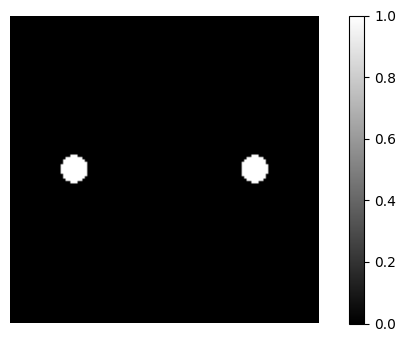

In [20]:
list_of_OAMs = []
output_chans = output_chan_symmetric(X,Y,output_chan_width, maxx,num_of_output_chans, chan_sep=channel_seperation)
#output_chans = output_chan_triangle(X,Y,output_chan_width, maxx,num_of_output_chans)
TotInt(output_chans[0] + output_chans[1] , phase=False)

Populating candidate input knotted fields

In [21]:
if(isKnot):
    for ii in range(len(knotType)):
        field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
        prop_field = field
        list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))
else:
    for ii in range(len(LG_modes)):
        ell, p = LG_modes[ii][0], LG_modes[ii][1]
        field = LG(r, phi, ell, p, w0, h, 0, k)
        prop_field = propTF(field, maxx, la, prop_dist)
        list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))

In [22]:
len(LG_modes)

2

Make a plot for each candidate knot

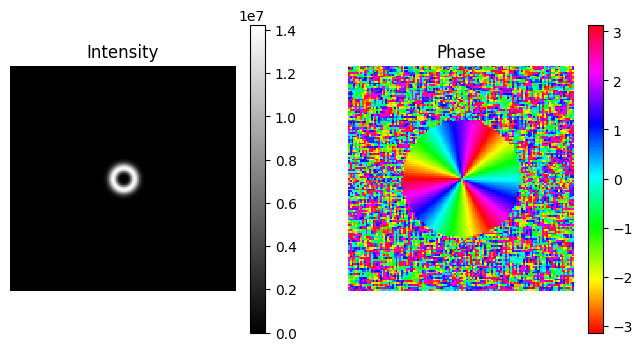

In [25]:
TotInt(list_of_OAMs[0].oamBeam)

Next, we need to prepare some phase screens. These will have to be random ones. 

To avoid crazy scattering effects, also apply a gaussian filter at the input

In [36]:
init_phase_maps = np.random.uniform(low=-np.pi, high=np.pi, size=(num_of_phase_maps, N, N))
complex_phase = np.empty((num_of_phase_maps, N, N), dtype=np.complex128)

for ii in range(num_of_phase_maps):
    # Apply extra gaussian filter on output data 
    init_phase_maps[ii] =sp.ndimage.gaussian_filter(init_phase_maps[ii], sigma=maxx*GFilterStrength)
    complex_phase[ii]= np.exp(1j*init_phase_maps[ii])

Plot the phase screen

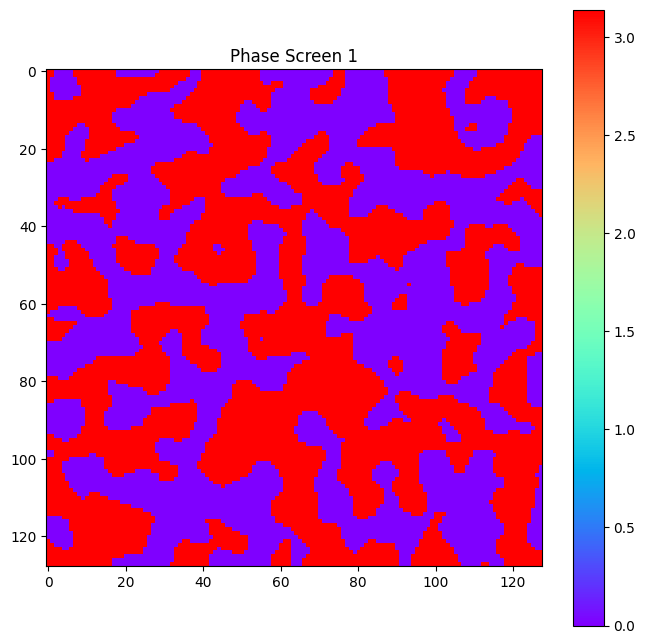

In [37]:
phase_screen_index=0

fig, ax = plt.subplots(1,1, figsize=(8,8))
first = ax.imshow(np.angle(init_phase_maps[phase_screen_index]), cmap='rainbow')
ax.set_title(f"Phase Screen {phase_screen_index+1}")
c1 = fig.colorbar(first, ax=ax)


# Imaging at the Lens (FFT)

We apply the phase pattern and image the lens at the far field of the lens. This reflects our original implementation of the Knot Sorter 

In [53]:
# First, normalize the incident beam
field = norm_field(list_of_OAMs[0].oamBeam, h)

# Apply the initial phase map to the field
field_mod_1 = field*init_phase_maps[0]

# Take the fourier transform of the lens! 
field_lens = fftshift(fft2(field_mod_1))

1.0


Plot the resulting phase pattern. What do we see? 

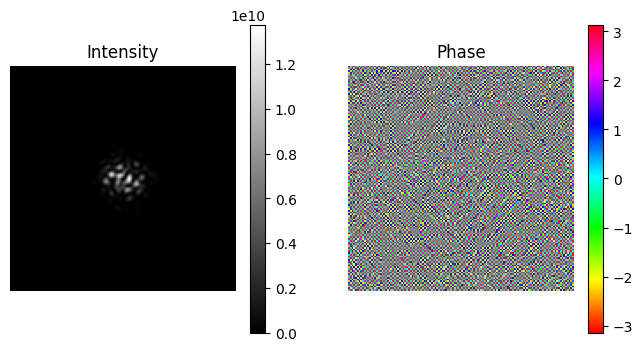

In [54]:
TotInt(field_lens)

# Using the Fresnel Propagator

Now, propagate the beam thorugh the phase plane using Fresnel diffraction. WLOG, we do this with the first beam in our set 

In [ ]:
# Choose a propagation distance
prop_dist = 20*cm

# First, normalize the incident field 
field = norm_field(list_of_OAMs[0].oamBeam, h)

# Modulate the field by the first phase map
field_mod_1 = field*init_phase_maps[0]

# Propagate the beam using the Fresnel Propagator
field_after = propTF(field_mod_1, maxx, la, prop_dist)

1.0


Now, check out the beam after propagation

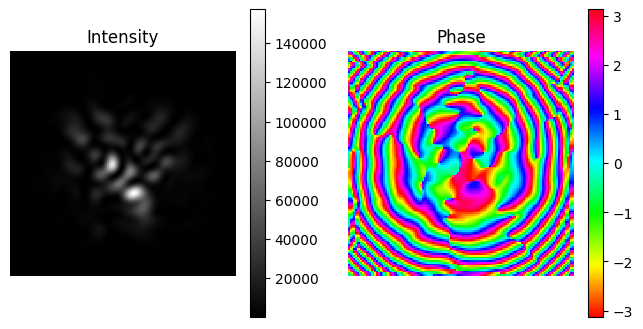

In [51]:
TotInt(field_after)

Modulate the field with another phase screen and propagate it by around the same length

In [44]:
field_mod_2 = field_after*init_phase_maps[1]

# Propagate the beam again using the Fresnel propgator

field_after_2 = propTF(field_mod_2, maxx, la, prop_dist)

Check out the beam again after propagation

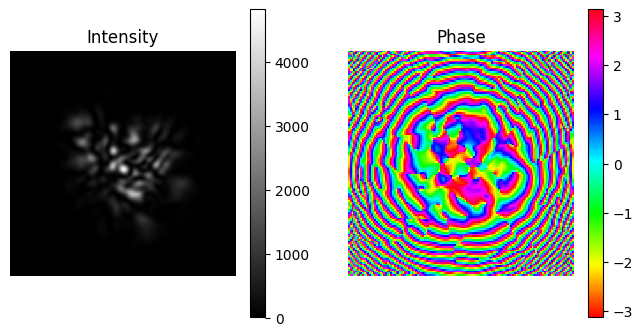

In [45]:
TotInt(field_after_2)

You may notice that, even in the single plane case, the scattering pattern occupies a greater range in our transverse field. This might be the reason why we end up using the lens instead: you no longer have to worry about propagating the beam by an arbitrary distance because you are sorting the beam at the far field.

... wait a minute, but if you are imaging the lens at the lens focal plane, then the beam is focused! So actually the resulting intensity pattern is compressed...

# Computing the Sorting Probability

** NEEDS TO BE UPDATED **

We'll need to define the fitness function, which is the sorting performance. For testing purposes, let's define a field having a gaussian beam at one of the three output_channels

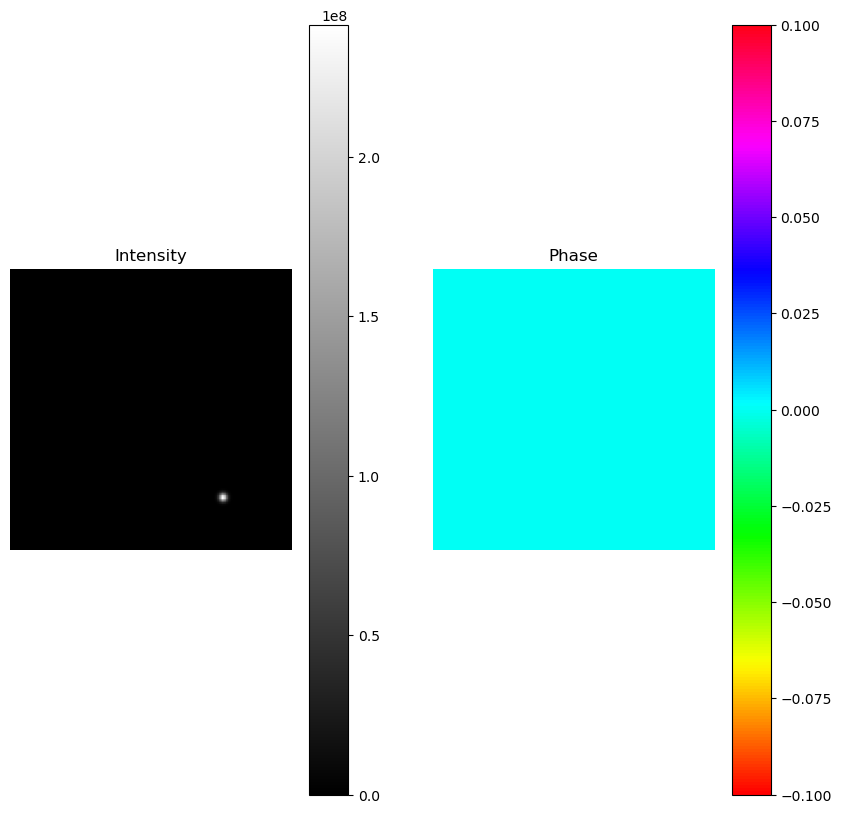

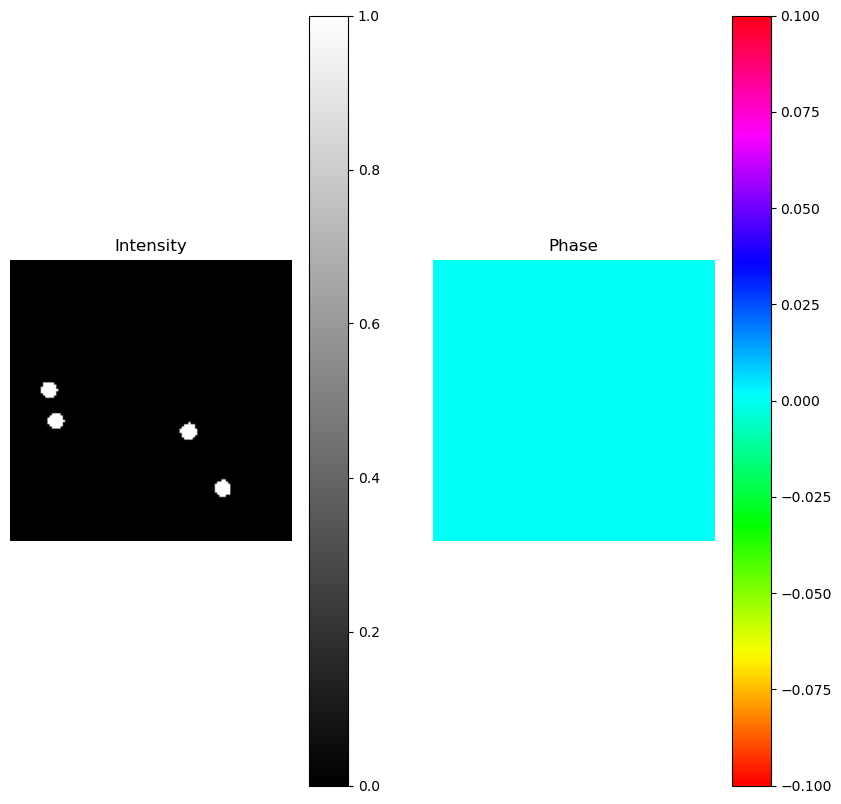

In [10]:
X_gauss=np.linspace(-maxx,maxx,N) + spot_loc_x[0]
Y_gauss=np.linspace(-maxx,maxx,N) + spot_loc_y[0]

h_gauss=np.abs(X[1]-X[2]) # Step size
xx_gauss,yy_gauss=np.meshgrid(X_gauss,Y_gauss)
r_gauss, phi_gauss= cart2pol(xx_gauss,yy_gauss)

# plotting the gaussian field 
gauss_field = LG(r_gauss, phi_gauss, 0, 0, 0.1*mm,h,0,k)
TotInt(gauss_field)
TotInt(np.sum(output_chans, axis=0))

We now compute the sorting performance. This can be done by taking the incident field and convolving it with the pupil array. 

In [11]:
# To normalize, we define the maximum sorting performance, which is the sum of intensities of each output channel

# max_output_intensity = np.sum(output_chans)

# plt.imshow(output_chans[0])

sorting_performance = 0 
ii = 0 # This defines mode n

# Define full set of indices, as you would summing through a for loop

full_index = np.arange(len(output_chans))   

# Delete ii from the list of full_index, creating a new temporary array
temp_index = np.delete(full_index, ii)
# Sum up the "incorrect" channels 
incorrect_chans = 0
for ind in temp_index:
    field_in_pupil = gauss_field*output_chans[ind]
    incorrect_chans += np.abs(field_in_pupil)**2
# Now, evaluate the sorting performance 
sorting_performance += np.abs(gauss_field*output_chans[ii])**2 - incorrect_chans 

# Genetic Algorithm

In [12]:
# Let's define a class that holds an OAM mode and its correponding output channel, defined from its centre

class oamModes():
    def __init__(self, oamBeam, output_chan_field):
        self.oamBeam = oamBeam 
        self.output_chan_field = output_chan_field

        

Create an array consisting of n OAM elements and m output channels

In [13]:
num_of_output_chans = 3
output_chans, spot_loc_x, spot_loc_y = output_chan(X,Y,0.1*mm,maxx,num_of_output_chans)

# Now create a list containing 'oamMode' objects 

list_of_OAMs = [oamModes(LG(r, phi, 1, 0, 0.2*mm,h,0,k), output_chans[0]), oamModes(LG(r, phi, -1, 0, 0.2*mm,h,0,k), output_chans[1])]

#field = LG(r, phi, 1, 0, 0.2*mm,h,0,k)
#TotInt(field)

[-0.0019022842504612283, -0.00021287128849936492, -0.0016914643241346312]


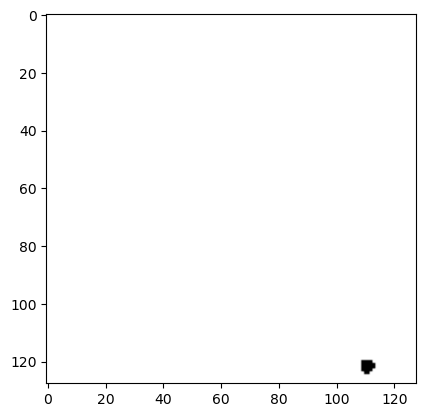

In [14]:
plt.imshow(np.abs(output_chans[0])**2, cmap = 'Greys')


We ... flatten them???

Define the fitness function. This will be the sorting performance function that we computed earlier

In [15]:
fourier_lens = 10*cm 

# Compute output channels

# num_of_output_chans = 2

# output_chans, _, _ = output_chan(X,Y,0.2*mm,maxx,num_of_output_chans)

num_of_phase_maps = 1 # 1 or 2 allowed only for now 

GFilterStrength = 500

fourierTransform = True

def fitness_func(ga_instance, solution, solution_idx):

    # Create the phase map(s) by reshaping the solution array
    phase_maps = np.empty((num_of_phase_maps, N, N))
    
    for ii in range(num_of_phase_maps):
        # Reshape solution to phase map 
        temp = np.reshape(solution[(ii)*N**2:(ii+1)*N**2], newshape=(N,N))
        # Apply gaussian filter 
        temp = sp.ndimage.gaussian_filter(temp, sigma=maxx*GFilterStrength)
        phase_maps[ii] = np.exp(1j*temp)
    
    # Now, this is the fitness parameter 

    sorting_performance = 0  

    for ii in range(len(list_of_OAMs)):

        # Define initial OAM field and correct output channel 

        field = list_of_OAMs[ii].oamBeam 
    
        # modulate the field by the first phase map 

        field_mod_1 = field*phase_maps[0]

        # let's simulate the propagation of the lens
        
        if (fourierTransform):
            field_lens = fftshift(fft2(field_mod_1))
        else:
            field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
    
        # What happens next depends on whether we have one or two phase maps
        
        if(num_of_phase_maps==1):
            # Compute the field intensity 
            final_field_int = np.abs(field_lens)**2
        else:
            # modulate the field by the second phase map 
            field_mod_2 = field_lens*phase_maps[1]
            # simulate the lens field again. This is the final field.
            
            if (fourierTransform):
                field_lens_2 = ifft2(ifftshift(fourField))
            else:
                field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                
            # compute the field intensity 
            final_field_int = np.abs(field_lens_2)**2
            
        # Define full set of indices, as you would summing through a for loop
        full_index = np.arange(len(output_chans))   
        # Delete ii from the list of full_index, creating a new temporary array
        temp_index = np.delete(full_index, ii)
        # Sum up the "incorrect" channels 
        incorrect_chans = 0
        for ind in temp_index:
            field_in_pupil = final_field_int*output_chans[ind]
            incorrect_chans += np.abs(field_in_pupil)**2
        # Now, evaluate the sorting performance 
        correct_chans = np.abs(final_field_int*output_chans[ii])**2
        sorting_performance += correct_chans - incorrect_chans 

    return np.mean(sorting_performance)


Parameters for the genetic algorithm. For ease, we store them in a yaml file. 

In [16]:
import pygad
import yaml 
from yaml import Loader 
import pickle as pkl

num_generations = 100
num_parents_mating =  2

fitness_function = fitness_func 

sol_per_pop = 10 # number of parents in the population?? 
num_genes = num_of_phase_maps*N**2 # This would refer to the number of parameters in our DNA

# Lower and upper-bound ranges of the parameterization. 

init_range_low = -np.pi
init_range_high = np.pi

parent_selection_type = "rank"
#K_tournament = 5 # number of contestants, essentially
#keep_elitism  = 1

crossover_type = "single_point"

mutation_type = "random"
mutation_percent_genes = 10 # probability of mutation 

# This function keeps track of the generation number + best fitness. Here, we also apply a blurring on the gaussian 

def on_gen(ga_instance):
    
    print("Generation : ", ga_instance.generations_completed)
    print("Fitness of the best solution :", ga_instance.best_solution()[1])
    print("Solution Parameters:", ga_instance.best_solution()[0])
    
    solution =  ga_instance.best_solution()[0]
    
    # Checkpoint current best model?
    
    instance_name = 'dummy_trial'
    
    # Create the phase map(s) by reshaping the solution array
    
    phase_maps = np.empty((num_of_phase_maps, N, N))
    
    for ii in range(num_of_phase_maps):
        phase_maps[ii] = np.exp(1j*np.reshape(a=solution[(ii)*N**2:(ii+1)*N**2], newshape = (N,N)))
    
    with open(f"best_phases/{instance_name}.pkl", 'wb') as file:
        pkl.dump(phase_maps, file)
    
    ga_instance.save(filename=f'genetic_instances/{instance_name}')
    
    # Save plot every 100 generations 
    
    if (ga_instance.generations_completed % 100 == 0):
        plt.figure()
        plt.plot(ga_instance.best_solutions_fitness)
        plt.savefig(f"plots/fitness_{ga_instance.generations_completed}.jpg")
        plt.show()
        
       

In [45]:
raggo = [2,3,4]

spiffy_sorted=[1,2,3,4,5]

spiffy_sorted[raggo]

TypeError: list indices must be integers or slices, not list

In [17]:
# Just incase ...
def wheel_cumulative_probs(ga_instance, probs, num_parents):
    
        """
        A helper function to calculate the wheel probabilities for these 2 methods:
            1) roulette_wheel_selection
            2) rank_selection
        It accepts a single 1D array representing the probabilities of selecting each solution.
        It returns 2 1D arrays:
            1) probs_start has the start of each range.
            2) probs_start has the end of each range.
        It also returns an empty array for the parents.
        """

        probs_start = numpy.zeros(probs.shape, dtype=float) # An array holding the start values of the ranges of probabilities.
        probs_end = numpy.zeros(probs.shape, dtype=float) # An array holding the end values of the ranges of probabilities.

        curr = 0.0

        # Calculating the probabilities of the solutions to form a roulette wheel.
        for _ in range(probs.shape[0]):
            min_probs_idx = numpy.where(probs == numpy.min(probs))[0][0]
            probs_start[min_probs_idx] = curr
            curr = curr + probs[min_probs_idx]
            probs_end[min_probs_idx] = curr
            # Replace 99999999999 by float('inf')
            # probs[min_probs_idx] = 99999999999
            probs[min_probs_idx] = float('inf')

        # Selecting the best individuals in the current generation as parents for producing the offspring of the next generation.
        if ga_instance.gene_type_single == True:
            parents = numpy.empty((num_parents, ga_instance.population.shape[1]), dtype=ga_instance.gene_type[0])
        else:
            parents = numpy.empty((num_parents, ga_instance.population.shape[1]), dtype=object)

        return probs_start, probs_end, parents

Let's pre-define a function which performs exponential rank selection

In [18]:
# c and k are empirical scaling factors that control the probability distribution. 
# c determines how well favoured fit individuals are
# k determines how peaked is the p-dist. 

c = 1.0
k = 1.0

def exp_rank_selection(fitness, num_parents, ga_instance):
    
    fitness_sorted = sorted(range(len(fitness)), key=lambda l: fitness[l])
    fitness_sorted.reverse()

    parents_sorted = np.empty((num_parents, ga_instance.population.shape[1]))

    # Create ranks 
    ranks = np.arange(1, ga_instance.sol_per_pop+1)

    # Now, compute the probabilities according to exponential selection routine
    probs = c*(1 - np.exp(-ranks/k))
    
    probs_start, probs_end, parents = ga_instance.wheel_cumulative_probs(probs=probs.copy(), 
                                                              num_parents=num_parents)

    parents_indices = []

    for parent_num in range(num_parents):
        rand_prob = np.random.rand()
        for idx in range(probs.shape[0]):
            if (rand_prob >= probs_start[idx] and rand_prob < probs_end[idx]):
            # The variable idx has the rank of solution but not its index in the population.
            # Return the correct index of the solution.
                mapped_idx = fitness_sorted[idx]
                parents[parent_num, :] = ga_instance.population[mapped_idx, :].copy()
                parents_indices.append(mapped_idx)
                break
                
    return parents, np.array(parents_indices)
    


Here, we can initialize our initial population in our way. Let's start with the OAM gratings that we want

C:\Users\tjaou104\AppData\Local\Temp\ipykernel_26304\2394624942.py:45: RuntimeWarning: invalid value encountered in divide
  sincc=np.sin(ss)/ss


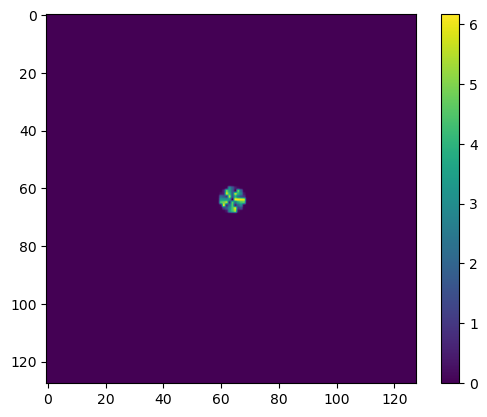

In [54]:
import random
        
# This function generates phase gratings in reminisce of OAM gratings 

def OAMWithGratings(l,rows,cols,xoffset,yoffset,a):
    
    crow, ccol = int(rows / 2)+xoffset, int(cols / 2)+yoffset
    mask = np.zeros((rows,cols))
    fx = 10.0
    fy = 0.0
    phi = np.zeros((rows,cols))

    for i in range (rows):
        for j in range (cols):
            
            x = i - crow
            y = j - ccol
            alpha = l*np.arctan2(x,y) + 2*np.pi*10*y/500
            g = a[0] + a[1]*np.cos(2*alpha)  + a[2]*np.cos(3*alpha) + a[3]*np.cos(4*alpha)
                  #g = 1/4*(1 + np.cos(alpha) + np.cos(2*alpha) +  np.cos(3*alpha)+np.cos(4*alpha))
                  #g = np.mod(alpha,2*np.pi)
            mask[i,j] = g
            

    return(mask)

# Blazed diffraction grating that we used to simulate creating a knotted beam using an SLM

def Hologram(A,hx,hy,LA): 
  # A -> Complex amplitude of the beam 
  # hx, hy -> x,y step-size
  # LA -> grating periodicity. This is usually expressed in terms of wavelength units
  # Normalization of the input beam
    
    nn=np.sum(np.abs(A)**2)*hx*hy
    NU=A/np.sqrt(nn)
      # Amplitude and phase pattern 
    Amp=np.abs(NU)
    PHI=np.angle(NU)
      # Grating
    mm=Amp.shape
    x1,y1=np.meshgrid(hx*np.arange(1,mm[1]+1),hy*np.arange(1,mm[0]+1))
      # Inverse Sinc fucntion
    ss=np.linspace(-np.pi,0,2000)
    sincc=np.sin(ss)/ss
    sincc[np.isnan(sincc)]=1
      # Amplitude masking 
    M=1+np.interp(Amp,sincc,ss)/np.pi
    M[np.isnan(M)]=0
      # Phase Hologram
    F=np.mod(PHI-np.pi*M+(2*np.pi*(x1+y1))/LA,2*np.pi)
      # Full Hologram
    return M*F


# With sorting hologram code

a = [1,0.5,0,0.1] # ... is this a fourier series????
SortingHologram = OAMWithGratings(1,500,500,0,0,a)
#plt.imshow(np.abs(SortingHologram))
plt.imshow(SortingHologram)

# With blazed diffraction grating 
random_l_mode = random.randint(-10,10)
LA = la*(1/np.random.uniform(0,1))
initial_field = LG(r, phi, random_l_mode, 0, w0, h, 0, k)
initial_field = initial_field/np.max(np.abs(initial_field))
holoGram = Hologram(initial_field, h,h,LA)
plt.imshow(holoGram)
plt.colorbar()


We create an initial population 

In [22]:
import scipy as sp


w0 = 0.02*mm

def initialize_population_sortingGuess(sol_per_pop, N, sigma):
    # Start with empty array to hold our starting maps
    
    init_pop = np.empty((sol_per_pop, N, N))
    
    for ii in range(sol_per_pop):
        
        # Stochastic Generator
        oamMode = np.random.randint(-2,2)
        a = [np.random.uniform(0.0,1.0) for ii in range(4)]
        x_offset = np.random.uniform(low=0.0, high=1.0)
        y_offset = np.random.uniform(low=0.0, high=1.0)
        
        # We may apply a random, normally distributed map w/ gaussian mean 
        gauss_mean = np.random.normal(0,0.1,(N,N))
        final_field = OAMWithGratings(oamMode,N,N,x_offset, y_offset, a) + gauss_mean
        
        # Apply a gaussian filter, too
        final_field = sp.ndimage.gaussian_filter(final_field, sigma=sigma)
        init_pop[ii] = final_field/np.max(np.abs(final_field))
        
    return init_pop


# Wraps a 2D field to the domain [-np.pi, +np.pi]
def wrap_to_domain(field):
    N = len(field)
    for ii in range(N):
        for jj in range(N):
            if(field[ii,jj] > np.pi):
                field[ii,jj] -= 2*np.pi
                
    return field


def initialize_population_blazed(sol_per_pop, N, sigma, num_phase_maps, isKnot):
    # Start with empty array to hold our starting maps
    
    init_pop = np.empty((sol_per_pop,num_phase_maps, N, N))
    
    for ii in range(sol_per_pop):
        for jj in range(num_phase_maps):
        
            # Stochastic Generator
            # Filp a coin
            coinfilp = np.random.randint(0,2)
            
            if(isKnot == False):
                oamMode = np.random.randint(-2,2)
                LA = la*(1/np.random.uniform(0,1))
                initial_field = LG(r, phi, random_l_mode, 0, w0, h, 0, k)
            else:
                # Filp another coin to determine trefoil or cinquefoil 
                coinfilp_2 = np.random.randint(0,2)
                if (coinfilp_2 == 0):
                    knotType='Trefoil'
                else:
                    knotType='Cinquefoil'
                a = np.random.uniform(0,1)
                b = np.random.uniform(0,1)
                s = 1.2
                initial_field = setKnotType(r, phi, w0, knotType, shapeParams) 

            initial_field = initial_field/np.max(np.abs(initial_field))
            LA = la*(1/np.random.uniform(0,1))
    
            # Stepsize in the x and y directions are randomized. This also applies stochasticsity on the generated maps
        
            hx = np.random.uniform(1e-3*h, h)
            hy = np.random.uniform(1e-3*h, h)

            # We may apply a random, normally distributed map w/ gaussian mean 
            gauss_mean = np.random.normal(0,0.1,(N,N))
            final_field = wrap_to_domain(Hologram(initial_field, hx, hy, LA))
            
            final_field += gauss_mean
            
            # Apply a gaussian filter, too
            final_field = sp.ndimage.gaussian_filter(final_field, sigma=sigma)
            final_field =  np.pi*(np.tanh(final_field))
            init_pop[ii,jj] = final_field
        
    return init_pop

In [23]:
g_filter_strength = 250

init_op = initialize_population_blazed(10,N,g_filter_strength*maxx,1, True)


NameError: name 'shapeParams' is not defined

In [24]:
# Reshape phase masks and plot

index_to_check = 4

plt.imshow(init_op[index_to_check,0])
plt.colorbar()

print(np.min(init_op[index_to_check,0]))

NameError: name 'init_op' is not defined

Let's define a slight modification to the usual rank selection routine: exponential probability instead of linear probability

Create the GA instance

In [25]:
ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       fitness_func=fitness_function,
                       sol_per_pop=sol_per_pop,
                       num_genes=num_genes,
                       init_range_low=init_range_low,
                       init_range_high=init_range_high,
                       parent_selection_type=exp_rank_selection,
                       crossover_type=crossover_type,
                       mutation_type=mutation_type,
                       mutation_percent_genes=mutation_percent_genes,
                       on_generation=on_gen)

Now run the GA

C:\Users\tjaou104\AppData\Local\Temp\ipykernel_12716\722896080.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  phase_maps[ii] = np.exp(1j*temp)


Generation :  1
Fitness of the best solution : 3506072507762.343
Solution Parameters: [ 2.82529982 -1.04038619 -2.91411226 ... -0.94069539 -1.41193825
 -0.10165241]
Generation :  2


C:\Users\tjaou104\AppData\Local\Temp\ipykernel_12716\4220199400.py:47: ComplexWarning: Casting complex values to real discards the imaginary part
  phase_maps[ii] = np.exp(1j*np.reshape(a=solution[(ii)*N**2:(ii+1)*N**2], newshape = (N,N)))


Fitness of the best solution : 4191911786016.9746
Solution Parameters: [ 2.82529982 -1.04038619 -2.91411226 ... -0.94069539 -1.41193825
 -0.10165241]
Generation :  3
Fitness of the best solution : 5964549274930.298
Solution Parameters: [ 2.82529982 -1.04038619 -2.91411226 ... -0.94069539 -1.41193825
  0.60329195]
Generation :  4
Fitness of the best solution : 8382214979361.795
Solution Parameters: [ 2.2827814  -1.04038619 -2.91411226 ... -0.94069539 -1.41193825
  0.55397611]
Generation :  5
Fitness of the best solution : 13116183286005.984
Solution Parameters: [ 3.56953156 -1.04038619 -2.91411226 ... -0.94069539 -1.41193825
  0.55397611]
Generation :  6
Fitness of the best solution : 22793452244770.688
Solution Parameters: [ 3.56953156 -1.04038619 -2.0496768  ... -0.94069539 -1.41193825
 -0.21973425]
Generation :  7
Fitness of the best solution : 30774323350212.64
Solution Parameters: [ 3.56953156 -1.24173159 -2.0496768  ... -0.94069539 -1.41193825
 -0.21973425]
Generation :  8
Fitness

Fitness of the best solution : 1.5228338764460678e+16
Solution Parameters: [ 3.7662706  -1.77924256 -1.16621412 ... -0.79589763 -2.12557266
 -0.48690109]
Generation :  53
Fitness of the best solution : 1.614128003373802e+16
Solution Parameters: [ 3.7662706  -1.77924256 -1.16621412 ... -0.79589763 -2.12557266
 -0.48690109]
Generation :  54
Fitness of the best solution : 1.6348967945358794e+16
Solution Parameters: [ 3.7662706  -1.77924256 -1.16621412 ... -0.79589763 -2.58790592
 -0.48690109]
Generation :  55
Fitness of the best solution : 1.6743411781027114e+16
Solution Parameters: [ 3.7662706  -1.77924256 -1.16621412 ... -0.79589763 -2.58790592
 -0.48690109]
Generation :  56
Fitness of the best solution : 1.8006506737572098e+16
Solution Parameters: [ 3.7662706  -1.77924256 -1.16621412 ... -0.79589763 -2.58790592
 -0.48690109]
Generation :  57
Fitness of the best solution : 2.0669476104485188e+16
Solution Parameters: [ 3.7662706  -1.77924256 -1.16621412 ... -0.79589763 -2.58790592
 -0.48

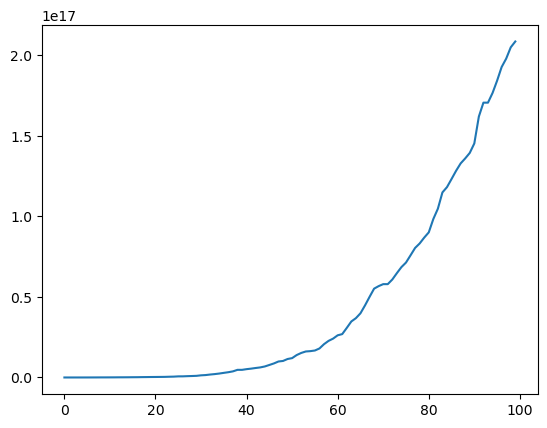

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


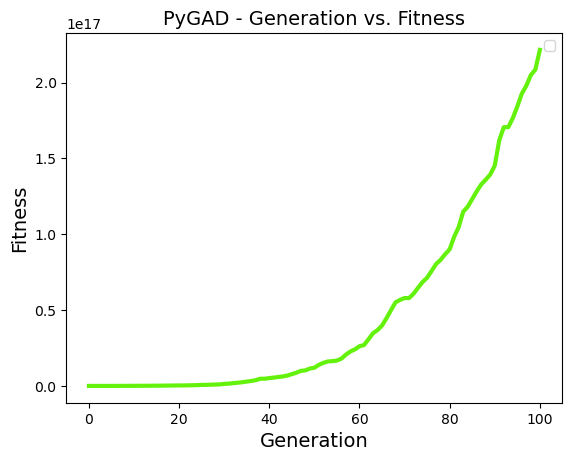

<Figure size 640x480 with 0 Axes>

In [26]:
import matplotlib.pyplot as plt

ga_instance.run()
ga_instance.plot_fitness()
plt.savefig('plots/figgy.png')

In [151]:
initialize_population(sol_per_pop,sol_per_pop)[0]

C:\Users\tjaou104\AppData\Local\Temp\ipykernel_18836\3238735699.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  init_pop[ii] = final_field.flatten()


array([ 1.51613707,  1.03615722,  0.65351114,  0.13874263,  0.71450817,
        1.34643635,  1.20693642, -0.38476042, -0.88271741, -0.10507902,
        1.31132453,  1.09337331,  0.67333759,  0.38324105,  0.63162597,
        1.32932931,  1.05497679, -0.47449593, -0.89080618,  0.62752274,
        1.07092856,  1.22761459,  1.22018193,  0.75012792,  0.19097712,
        1.15931395,  0.96877421, -0.72079946, -0.37457611,  1.50845584,
        0.70027239,  1.14199725,  1.54092671,  1.10474084,  0.23671199,
        0.81337741,  0.71853272, -1.16001511,  0.47133804,  2.52077353,
        0.60586221,  0.89377672,  1.15722436,  1.33682237,  0.9284683 ,
        0.42419601,  0.71599494, -0.33612134,  2.42633026,  2.93656351,
        0.4012033 ,  0.33860606,  0.61727245,  0.87051445,  0.99647988,
        1.20710466, -0.10668903,  2.9764456 ,  2.55272254,  1.51748216,
        0.4370375 ,  0.11453396,  0.38206742,  0.43338023,  0.46127574,
        0.61170828,  0.721871  , -0.97763124, -0.34637839, -0.60

# Analyzing the Solution of the GA 

extract the solution, and reshape it in an interpretable form 

In [27]:
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print("Parameters of the best solution : {solution}".format(solution=solution))
print("Fitness value of the best solution = {solution_fitness}".format(solution_fitness=solution_fitness))


Parameters of the best solution : [ 1.33048594 -2.52747685  0.45455953 ... -2.59931303 -1.6375629
 -0.17792757]
Fitness value of the best solution = 2.2151395596137523e+17


C:\Users\tjaou104\AppData\Local\Temp\ipykernel_12716\722896080.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  phase_maps[ii] = np.exp(1j*temp)


Save the genetic instance

In [173]:
instance_name = 'dummy_test'
ga_instance.save(filename=f'genetic_instances/{instance_name}')

Let's analyze what we've made

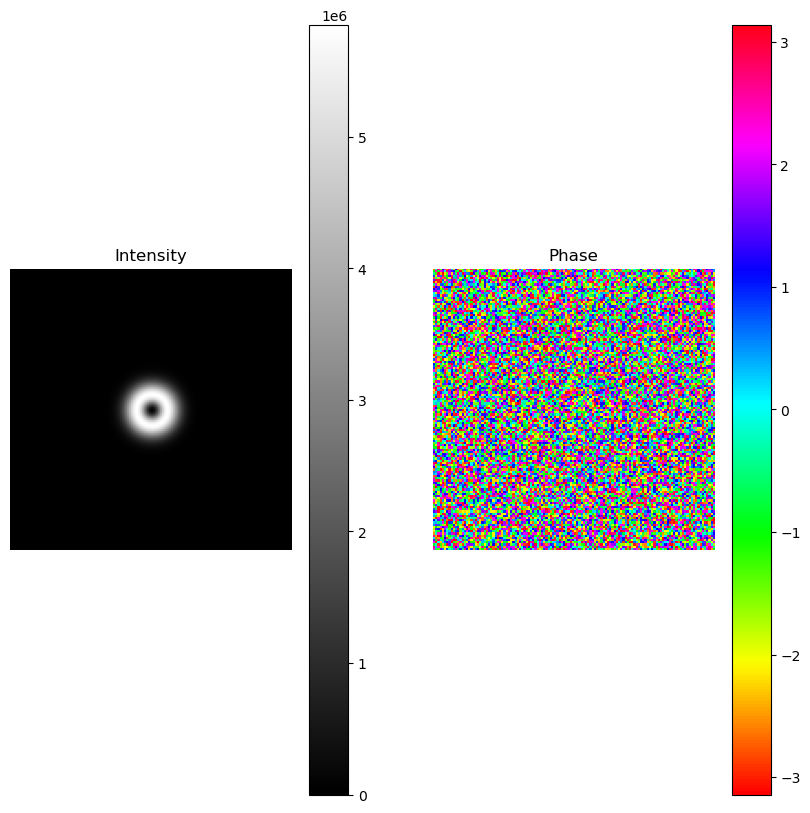

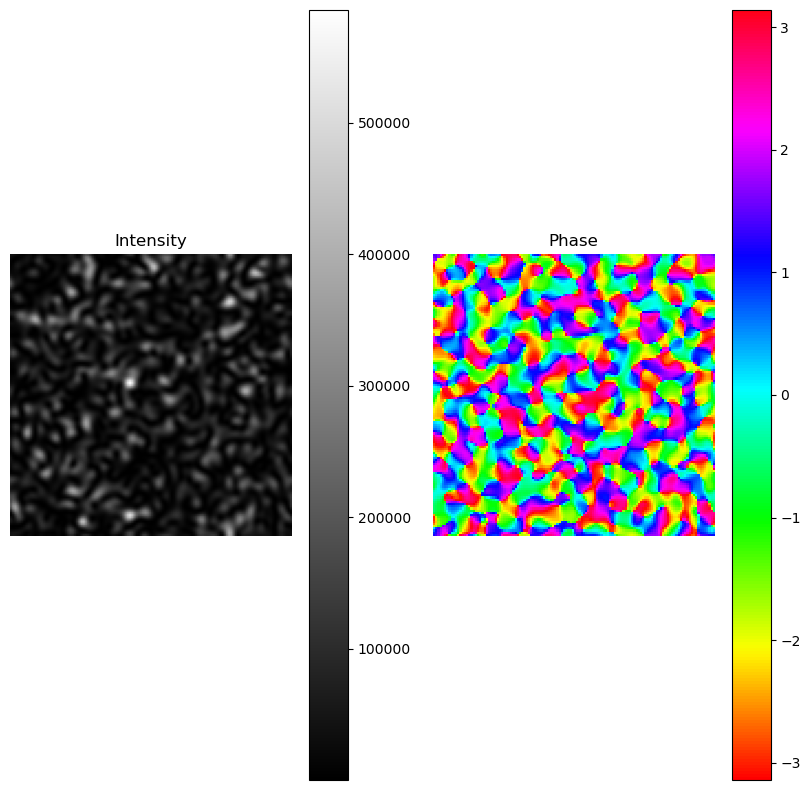

In [28]:
# Let's pick an LG beam to analyze

field = list_of_OAMs[1].oamBeam 

# Create the phase map by reshaping the solution array

reshape_phase_1 = np.reshape(a=solution[0:N**2], newshape = (N,N))
#reshape_phase_2 = np.reshape(a=solution[N**2:2*N**2], newshape=(N,N))
phase_map_1 = np.exp(1j*reshape_phase_1)
#phase_map_2 = np.exp(1j*reshape_phase_2)

# modulate the field by the first phase map 

field_mod_1 = field*phase_map_1

TotInt(field_mod_1)

# let's simulate the propagation of the lens

field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)

TotInt(field_lens)

# modulate the field by the second phase map 

#field_mod_2 = field_lens*phase_map_2

#TotInt(field_mod_2)

# simulate the lens field again. This is the final field. 

#field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)


#TotInt(field_lens_2)

# compute the field intensity 

#final_field_int = np.abs(field_lens_2)**2

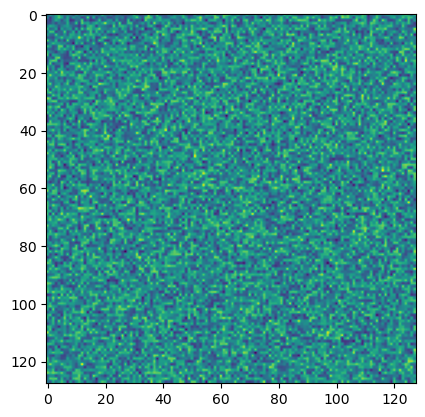

In [40]:
plt.imshow(reshape_phase_1)

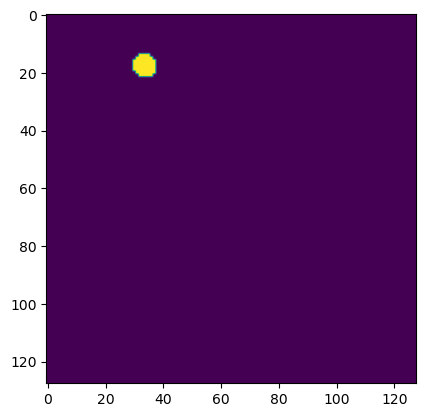

In [223]:

plt.imshow(np.abs(output_chans[1])**2)